# Dynamic Notional — Math Floor + Global MaxDD + Asymmetric Ceiling

## Logic

### Math Floor (per-cycle loss cap)
At each roll, size the position so that if the call expires worthless (TSLL flat/down), the loss doesn't exceed `target_local` as a fraction of equity:
```
C_pct    = C / S_t                          # call premium as % of spot
pf_local = target_local / C_pct             # pure math, no HWM
```

### Global MaxDD (portfolio-level drawdown cap)
Also size so that even in the worst case this cycle, equity can't breach `global_maxdd_limit` from the all-time high:
```
ATH       = equity.cummax() up to today
headroom  = equity_now - ATH * (1 - global_maxdd_limit)
pf_global = headroom / (C_pct * equity_now)   if headroom > 0 else 0.0
```

### Combined sizing (every roll — expiry or ceiling trigger)
```
pf       = min(1.0, pf_local, pf_global)
n_sh     = min(pf * equity_now / S_t, notional / S0)   # capped at static reference (n_sh_max)
cash_bal = equity_now - n_sh * S_t                     # FIXED for the cycle, earns R_RF daily
```
`S0` is the TSLL spot on the first simulation date — the same reference price the static
"prior best" baseline (`guaranteed_floor_hybrid_sandbox.ipynb`) uses for its fixed share
count. Capping at `n_sh_max` means the `pf=1.0`, no-floor, no-global-cap, no-ceiling
baseline below tracks that static result (identical while the cap binds; can drift if
equity ever dips enough to uncap between rolls — flagging this rather than claiming an
exact match).

**Guardrail:** `target_local` must be strictly less than `global_maxdd_limit`, or the very
first cycle's local floor alone could already exhaust global risk capacity (`pf_global = 0`
the moment it binds, with no cycles run beforehand to justify it). The notebook asserts
this at every call to `simulate()`. At `target_local=8%` / `global_maxdd=15%` the margin is
7pp — a 10% global cap (2pp margin) made `pf_global` bind hard even after tiny dips from
ATH, producing a very choppy per-cycle deployment (mean pf 23%, ranging 2%–57%). This wider
margin should let `pf_global` bind less aggressively and give smoother, more consistent
capital deployment — that's what this pass is checking.

### Ceiling (intra-cycle take-profit) — corrected
If cumulative cycle return hits `+ceiling_pct` before expiry → **close immediately and
re-enter fresh the same day**, through the exact same 3-tier selection/sizing path as an
expiry-triggered roll (fresh contract, fresh `pf` from the new `equity_now`). No cash-wait
to the original expiry — that approach let equity sit idle earning only `R_RF`, then
re-deployed at an already-inflated equity level, which made drawdowns *worse*, not better.

**Update from the first pass:** every ceiling sweep run so far (10-30% at global_maxdd=20%,
30% at global_maxdd=15%, and 10-30% at global_maxdd=10%) has shown CAGR and Calmar getting
monotonically *worse* the tighter the ceiling — every tested value underperformed "no
ceiling," in every configuration. Two effects compound: (1) each trigger forces a full fresh
90-DTE premium purchase, discarding whatever time value was left in the closed contract, and
(2) locking in a gain sets a new ATH, so the *next* cycle's ordinary variance gets measured
as drawdown from that freshly-ratcheted peak. Net: `CEILING` is kept loose (40%) as a
rarely-firing safety valve, not an active lever.

### Floor is expiry-only
The floor guarantee only holds if the position is run to true expiry (short stock + long
call converge to delta-neutral only near expiry). A floor breach that shows up *intraday*
is not a bug — we never close early for it. Only ceiling triggers close early, and only on
gains. Note this also means `global_maxdd_limit` only constrains sizing decisions *at roll
time* (worst-case-at-expiry) — it does not clamp the daily mark-to-market path between
rolls, so realized MaxDD can land slightly worse than the stated limit if there's a large
adverse intra-cycle move before the next roll.

### What happens when `pf_global` hits 0
This means equity has already fallen to `ATH * (1 - global_maxdd_limit)` going into a roll.
The position parks in 100% cash earning `R_RF`. Since `ATH` stays fixed while parked (no new
highs are being made) and cash compounds daily, `headroom` strictly increases every day — it
is mathematically guaranteed to reopen, just possibly slowly. Not a spiral to zero, and
distinct from a misconfiguration (`target_local ≥ global_maxdd_limit`) where cycle 1 alone
could zero it out — that case is blocked by the assertion above.

### Prior best result (reference, not re-run here)
Static fixed `n_sh` (`guaranteed_floor_hybrid_sandbox.ipynb`): **CAGR +19.42%, MaxDD −19.70%,
Sharpe 0.928, Calmar 0.986**. The dynamic variants below need to beat this on **Calmar** to
be worth using. At `target_local=8%`/`global_maxdd=10%`/no ceiling, we already cleared that
bar (Calmar 1.097, Sharpe 0.993, MaxDD -11.68%) but capital deployment was very choppy
(mean pf 23%, 2%-57% range) — this pass checks whether loosening to 15% keeps that Calmar
edge while smoothing out deployment.

### On parameter optimization
Deliberately **not** running a Sharpe/Calmar-maximizing grid search yet. The backtest has
~16-18 total cycles and, across every ceiling configuration tested so far, only 0-1
triggers per run — an optimizer let loose on that few independent events would fit noise
from a handful of historical episodes, not find a robust edge. If/when we do explore a
wider grid, it should be a small, economically-motivated set of combos reported as
in-sample/exploratory, ideally checked against a holdout split (see the
`holdout_validation_sandbox.ipynb` pattern already in `scripts/utils/sandbox/`) before
trusting any "winner."

### Variants (this pass — global MaxDD loosened back to 15% for smoother deployment)
| | pf_local (target_local) | pf_global (global_maxdd) | Ceiling |
|---|---|---|---|
| **Baseline** | off (1.0) | off | — |
| **Math Floor** | 8% | off | — |
| **Math Floor + Global MaxDD** | 8% | 15% | — |
| **Math Floor + Global MaxDD + Ceiling** | 8% | 15% | +40% (loose safety valve) |


In [43]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../../scripts/eda')
sys.path.insert(0, '../../scripts/backtest')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from data_loader import load_tsll, load_tsll_calls, load_tsla_underlying, load_tsla_calls
from options_selection import select_contract, bs_delta

plt.style.use('seaborn-v0_8-whitegrid')

tsll_spot  = load_tsll().set_index('Date')['Close']
tsll_calls = load_tsll_calls()
tsla_spot  = load_tsla_underlying().set_index('Date')['Close'].reindex(tsll_spot.index).ffill()
tsla_calls = load_tsla_calls()

tsll_lut = tsll_calls.set_index(['raw_id', 'date'])['px_last'].to_dict()
tsla_lut = tsla_calls.set_index(['raw_id', 'date'])['px_last'].to_dict()

tsla_sig = (tsla_spot.pct_change().rolling(21).std() * 252**0.5).ffill().bfill()
tsll_sig = (tsll_spot.pct_change().rolling(21).std() * 252**0.5).ffill().bfill()

tsll_cvol = tsll_calls[tsll_calls['px_volume'] > 0].copy()
tsll_cvol['dte']       = (pd.to_datetime(tsll_cvol['expiry']) - pd.to_datetime(tsll_cvol['date'])).dt.days
tsll_cvol['spot']      = tsll_cvol['date'].map(tsll_spot)
tsll_cvol['moneyness'] = tsll_cvol['strike'] / tsll_cvol['spot']

sim_dates = tsll_spot.index[tsll_spot.index >= tsll_cvol['date'].min()]

TARGET_DTE   = 90
MAX_DTE      = 110
LEVER        = 2.0
R_RF         = 0.05
R_RF_D       = R_RF / 252
TARGET_LOCAL = 0.08   # per-cycle floor: max loss as % of equity if the call expires worthless
GLOBAL_MAXDD = 0.15   # portfolio-level: max drawdown from ATH this cycle's worst case can cause
CEILING      = 0.40   # intra-cycle take-profit trigger -- kept loose; tight ceilings were shown
                       # to hurt monotonically in the earlier 15/20/25/30% sweep (extra full-
                       # premium repurchases + ATH ratchet effect), so this is a rarely-firing
                       # safety valve, not an active lever

print(f'Data loaded. Sim: {sim_dates[0].date()} → {sim_dates[-1].date()}  ({len(sim_dates)} days)')

Data loaded. Sim: 2022-08-12 → 2026-06-10  (960 days)


In [44]:
# ── Helpers ───────────────────────────────────────────────────────────────────

def _select_tsll_relaxed(d):
    day = tsll_cvol[tsll_cvol['date'] == d]
    w = day[(day['dte'] >= 45) & (day['dte'] <= 120)
            & (day['moneyness'] >= 0.80) & (day['moneyness'] <= 1.20)]
    if w.empty:
        return None
    w = w.copy()
    w['ad'] = (w['moneyness'] - 1.0).abs()
    w['dd'] = (w['dte'] - TARGET_DTE).abs()
    return w.sort_values(['ad', 'dd']).iloc[0]


def _mtm(p, d):
    lut = tsll_lut if p['ul'] == 'tsll' else tsla_lut
    sp  = tsll_spot if p['ul'] == 'tsll' else tsla_spot
    if d > p['e']:
        return max(float(sp.loc[d]) - p['K'], 0.0)
    v = lut.get((p['id'], d))
    return float(v) if v is not None and not pd.isna(v) else p['px']


def _compute_pf(C_pct, eq_now, ath, target_local, global_maxdd_limit):
    """Deployment fraction: min of the local floor and global MaxDD constraints.

    pf_local  caps this cycle's worst-case loss (call expires worthless) at
              `target_local` of current equity.
    pf_global caps that same worst-case loss so it can't push equity below
              ATH * (1 - global_maxdd_limit). 0 if that headroom is already gone.
    """
    pf_local = (target_local / C_pct) if target_local else 1.0

    if global_maxdd_limit is not None:
        headroom  = eq_now - ath * (1.0 - global_maxdd_limit)
        pf_global = (headroom / (C_pct * eq_now)) if headroom > 0 else 0.0
    else:
        pf_global = 1.0

    return max(0.0, min(1.0, pf_local, pf_global))


print('Helpers defined.')

Helpers defined.


In [45]:
# ── Simulation ────────────────────────────────────────────────────────────────

def simulate(sim_dates, target_local=None, global_maxdd_limit=None, ceiling_pct=None, notional=1.0):
    """
    target_local       : None -> pf_local=1.0 (no floor)  | 0.10 -> cap per-cycle worst-case
                          loss (call expires worthless) at 10% of equity
    global_maxdd_limit : None -> pf_global=1.0 (no cap)   | 0.20 -> cap that same worst-case
                          loss so equity can't breach a 20% drawdown from its all-time high
    ceiling_pct        : None -> no take-profit           | 0.25 -> close + re-enter fresh at
                          +25% intra-cycle gain

    At every roll (expiry OR ceiling trigger):
        C_pct    = C / S_t
        pf       = min(1, target_local/C_pct, pf_global)     (see _compute_pf)
        n_sh     = min(pf * equity_now / S_t, notional / S0)  # capped at static reference
        cash_bal = equity_now - n_sh * S_t                    # FIXED for the cycle

    Ceiling: closes immediately and re-enters the same day through the identical 3-tier
    selection/sizing path as an expiry roll -- no cash-wait to the original expiry.
    Floor: never closes early on a breach; only guaranteed at true expiry.
    """
    if target_local is not None and global_maxdd_limit is not None:
        assert target_local < global_maxdd_limit, (
            f"target_local ({target_local:.0%}) must be < global_maxdd_limit "
            f"({global_maxdd_limit:.0%}) -- otherwise cycle 1 alone can exhaust "
            f"all risk capacity."
        )

    S0       = float(tsll_spot.loc[sim_dates[0]])
    n_sh_max = notional / S0

    equity     = pd.Series(index=sim_dates, dtype=float)
    spnl = opnl = cpnl = 0.0
    Sp         = S0
    pc = pa    = None
    n_sh       = 0.0
    cash_bal   = notional
    eq_at_roll = notional
    ath        = notional
    log        = []
    cur        = None

    for d in sim_dates:
        St = float(tsll_spot.loc[d])

        # Daily P&L
        spnl += n_sh * (Sp - St)
        cpnl += cash_bal * R_RF_D          # cash_bal fixed since the last roll
        Sp    = St

        for p in [pc, pa]:
            if p is None:
                continue
            px      = _mtm(p, d)
            opnl   += p['n'] * 100 * (px - p['px'])
            p['px'] = px

        eq_now = notional + spnl + opnl + cpnl
        ath    = max(ath, eq_now)

        # Ceiling check -- either leg open counts as "in a position"
        ceiling_hit = (
            ceiling_pct is not None
            and (pc is not None or pa is not None)
            and (eq_now - eq_at_roll) / eq_at_roll >= ceiling_pct
        )

        exp     = pc['e'] if pc else (pa['e'] if pa else None)
        do_roll = (exp is None) or (d > exp) or ceiling_hit

        if do_roll:
            if cur is not None:
                cur.update({'ee': eq_now, 'end': d, 'ceiling': ceiling_hit})
                log.append(cur)
            pc = pa    = None
            eq_at_roll = eq_now

            # ── Tier 1: strict TSLL ATM 60-110 DTE ───────────────────────────
            row = select_contract(tsll_calls, tsll_spot, d, 'ATM', TARGET_DTE, max_dte=MAX_DTE)
            if row is not None:
                C, K     = float(row['px_last']), float(row['strike'])
                C_pct    = C / St
                pf       = _compute_pf(C_pct, eq_now, ath, target_local, global_maxdd_limit)
                n_sh     = min(pf * eq_now / St, n_sh_max)
                cash_bal = eq_now - n_sh * St
                n_ct     = n_sh / 100
                pc  = {'ul': 'tsll', 'id': row['raw_id'], 'K': K,
                       'e': row['expiry'], 'n': n_ct, 'px': C}
                cur = {'start': d, 'es': eq_now, 'pf': pf, 'tier': 'TSLL full',
                       'C_pct': C_pct*100, 'floor_pct': -pf*C_pct*100, 'ceiling': False}

            else:
                # ── Tier 2: relaxed TSLL + TSLA delta supplement ──────────────
                rr = _select_tsll_relaxed(d)
                if rr is not None:
                    C, K     = float(rr['px_last']), float(rr['strike'])
                    exp_r    = pd.Timestamp(rr['expiry'])
                    C_pct    = C / St
                    pf       = _compute_pf(C_pct, eq_now, ath, target_local, global_maxdd_limit)
                    n_sh     = min(pf * eq_now / St, n_sh_max)
                    cash_bal = eq_now - n_sh * St
                    n_ct     = n_sh / 100
                    pc    = {'ul': 'tsll', 'id': rr['raw_id'], 'K': K,
                             'e': exp_r, 'n': n_ct, 'px': C}
                    cur   = {'start': d, 'es': eq_now, 'pf': pf, 'tier': 'TSLL+TSLA',
                             'C_pct': C_pct*100, 'floor_pct': -pf*C_pct*100, 'ceiling': False}
                    T_l   = max((exp_r - d).days / 365.25, 1/365.25)
                    sig_l = float(tsll_sig.loc[d]) if d in tsll_sig.index else 0.5
                    dl    = bs_delta(St, K, T_l, R_RF, sig_l)
                    gap   = max(LEVER * n_sh * St - dl * n_ct * 100 * St, 0.0)
                    if gap > 0:
                        ra = select_contract(tsla_calls, tsla_spot, d, 'ATM',
                                             TARGET_DTE, max_dte=MAX_DTE)
                        if ra is not None:
                            Sa    = float(tsla_spot.loc[d])
                            T_a   = (ra['expiry'] - d).days / 365.25
                            sig_a = float(tsla_sig.loc[d]) if d in tsla_sig.index else 0.5
                            da    = bs_delta(Sa, float(ra['strike']), T_a, R_RF, sig_a)
                            nt    = gap / (max(da, 0.01) * 100 * Sa)
                            pa    = {'ul': 'tsla', 'id': ra['raw_id'],
                                     'K': float(ra['strike']), 'e': ra['expiry'],
                                     'n': nt, 'px': float(ra['px_last'])}
                else:
                    # ── Tier 3: TSLA only (best-effort; floor math is approximate) ─
                    ra = select_contract(tsla_calls, tsla_spot, d, 'ATM',
                                         TARGET_DTE, max_dte=MAX_DTE)
                    if ra is not None:
                        Sa, Ca   = float(tsla_spot.loc[d]), float(ra['px_last'])
                        C_pct    = Ca / Sa
                        pf       = _compute_pf(C_pct, eq_now, ath, target_local, global_maxdd_limit)
                        n_sh     = min(pf * eq_now / St, n_sh_max)
                        cash_bal = eq_now - n_sh * St
                        T_a   = (ra['expiry'] - d).days / 365.25
                        sig_a = float(tsla_sig.loc[d]) if d in tsla_sig.index else 0.5
                        da    = bs_delta(Sa, float(ra['strike']), T_a, R_RF, sig_a)
                        nt    = (LEVER * n_sh * St) / (max(da, 0.01) * 100 * Sa)
                        pa    = {'ul': 'tsla', 'id': ra['raw_id'],
                                 'K': float(ra['strike']), 'e': ra['expiry'],
                                 'n': nt, 'px': Ca}
                        cur   = {'start': d, 'es': eq_now, 'pf': pf, 'tier': 'TSLA only',
                                 'C_pct': C_pct*100, 'floor_pct': float('nan'), 'ceiling': False}
                    else:
                        n_sh     = 0.0
                        cash_bal = eq_now
                        cur = {'start': d, 'es': eq_now, 'pf': 0.0, 'tier': 'cash',
                               'C_pct': float('nan'), 'floor_pct': float('nan'), 'ceiling': False}

        equity.loc[d] = eq_now

    if cur is not None:
        cur.update({'ee': equity.iloc[-1], 'end': sim_dates[-1], 'ceiling': False})
        log.append(cur)

    cdf = pd.DataFrame(log)
    if not cdf.empty:
        cdf['rpct'] = (cdf['ee'] - cdf['es']) / cdf['es'] * 100
    return equity, cdf


print('simulate() defined.')

simulate() defined.


In [46]:
# ── Run the four variants ───────────────────────────────────────────────────
print('Baseline (pf=1.0, capped, no floor, no global cap, no ceiling)...')
eq_base, cdf_base = simulate(sim_dates, target_local=None, global_maxdd_limit=None, ceiling_pct=None)

print(f'Math Floor only (target_local={TARGET_LOCAL:.0%}, no global cap, no ceiling)...')
eq_floor, cdf_floor = simulate(sim_dates, target_local=TARGET_LOCAL, global_maxdd_limit=None, ceiling_pct=None)

print(f'Math Floor + Global MaxDD (target_local={TARGET_LOCAL:.0%}, global_maxdd={GLOBAL_MAXDD:.0%}, no ceiling)...')
eq_global, cdf_global = simulate(sim_dates, target_local=TARGET_LOCAL, global_maxdd_limit=GLOBAL_MAXDD, ceiling_pct=None)

print(f'Math Floor + Global MaxDD + Ceiling (target_local={TARGET_LOCAL:.0%}, global_maxdd={GLOBAL_MAXDD:.0%}, ceiling={CEILING:.0%})...')
eq_full, cdf_full = simulate(sim_dates, target_local=TARGET_LOCAL, global_maxdd_limit=GLOBAL_MAXDD, ceiling_pct=CEILING)

print('Done.')

Baseline (pf=1.0, capped, no floor, no global cap, no ceiling)...
Math Floor only (target_local=8%, no global cap, no ceiling)...
Math Floor + Global MaxDD (target_local=8%, global_maxdd=15%, no ceiling)...
Math Floor + Global MaxDD + Ceiling (target_local=8%, global_maxdd=15%, ceiling=40%)...
Done.


In [ ]:
# ── Summary stats ─────────────────────────────────────────────────────────────
def stats(eq, label, cdf=None):
    ret    = eq.pct_change().dropna()
    n_yrs  = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr   = eq.iloc[-1] ** (1 / n_yrs) - 1
    sharpe = ret.mean() / ret.std() * 252**0.5
    maxdd  = (eq / eq.cummax() - 1).min()
    calmar = cagr / abs(maxdd)
    n_c    = int(cdf['ceiling'].sum()) if cdf is not None and 'ceiling' in cdf.columns else 0
    avg_pf = float(cdf['pf'].mean())   if cdf is not None else 1.0
    return dict(Strategy=label, CAGR=cagr, Sharpe=sharpe,
                MaxDD=maxdd, Calmar=calmar, AvgPF=avg_pf, CeilingHits=n_c)

rows = [
    stats(eq_base,   'Baseline  (pf=1.0, capped)',                      cdf_base),
    stats(eq_floor,  f'Math Floor  (target −{TARGET_LOCAL:.0%})',       cdf_floor),
    stats(eq_global, f'+ Global MaxDD  (−{GLOBAL_MAXDD:.0%} from ATH)', cdf_global),
    stats(eq_full,   f'+ Ceiling  (+{CEILING:.0%})',                    cdf_full),
]
summary = pd.DataFrame(rows).set_index('Strategy')

# Reference row: static fixed n_sh from guaranteed_floor_hybrid_sandbox.ipynb (not re-run here)
summary.loc['Prior best (static, reference)'] = [0.1942, 0.928, -0.1970, 0.986, 1.0, 0]

fmt = {'CAGR':'{:+.2%}','Sharpe':'{:.3f}','MaxDD':'{:.2%}',
       'Calmar':'{:.3f}','AvgPF':'{:.0%}','CeilingHits':'{:.0f}'}
display(
    summary.style.format(fmt)
    .set_caption(f'Math Floor + Global MaxDD + Ceiling  |  {sim_dates[0].date()} – {sim_dates[-1].date()}')
)

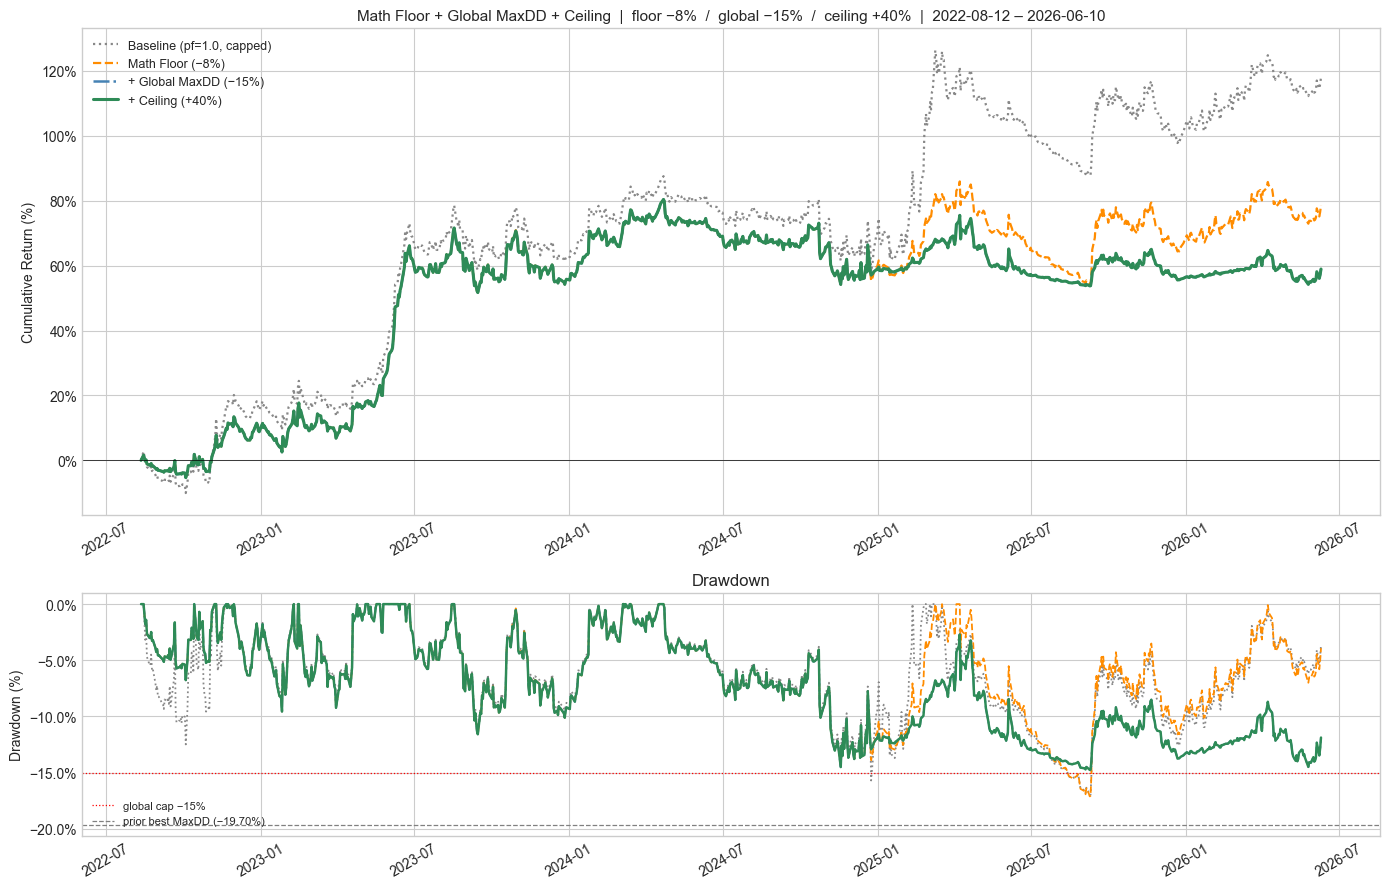

Chart saved.


In [48]:
# ── Chart: equity curves + drawdown ───────────────────────────────────────────
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(14, 9),
                                gridspec_kw={'height_ratios': [3, 1.5]})
specs = [
    (eq_base,   cdf_base,   '#888888',   ':',  1.6, 'Baseline (pf=1.0, capped)'),
    (eq_floor,  cdf_floor,  'darkorange','--', 1.6, f'Math Floor (−{TARGET_LOCAL:.0%})'),
    (eq_global, cdf_global, 'steelblue', '-.', 1.8, f'+ Global MaxDD (−{GLOBAL_MAXDD:.0%})'),
    (eq_full,   cdf_full,   'seagreen',  '-',  2.2, f'+ Ceiling (+{CEILING:.0%})'),
]
for eq, cdf, col, ls, lw, lbl in specs:
    ax0.plot(eq.index, (eq-1)*100, color=col, ls=ls, lw=lw, label=lbl)
    ax1.plot((eq/eq.cummax()-1).index, (eq/eq.cummax()-1)*100, color=col, ls=ls, lw=lw*0.8)

# Ceiling trigger markers (full variant)
ceil_ends = cdf_full[cdf_full['ceiling']]['end']
for cd in ceil_ends:
    if cd in eq_full.index:
        ax0.axvline(cd, color='seagreen', lw=0.5, alpha=0.35, ls=':')

ax0.axhline(0, color='black', lw=0.5)
ax0.yaxis.set_major_formatter(mticker.PercentFormatter())
ax0.set_ylabel('Cumulative Return (%)')
ax0.set_title(
    f'Math Floor + Global MaxDD + Ceiling  |  '
    f'floor −{TARGET_LOCAL:.0%}  /  global −{GLOBAL_MAXDD:.0%}  /  ceiling +{CEILING:.0%}  |  '
    f'{sim_dates[0].date()} – {sim_dates[-1].date()}',
    fontsize=11
)
ax0.legend(loc='upper left', fontsize=9)
if len(ceil_ends):
    ax0.annotate(f'Dotted vlines = ceiling hit ({len(ceil_ends)}×, full variant)',
                 xy=(0.01, 0.04), xycoords='axes fraction', fontsize=8, color='seagreen')

ax1.axhline(-GLOBAL_MAXDD*100, color='red',  lw=0.9, ls=':',  label=f'global cap −{GLOBAL_MAXDD:.0%}')
ax1.axhline(-19.70,            color='grey', lw=0.9, ls='--', label='prior best MaxDD (−19.70%)')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.set_ylabel('Drawdown (%)')
ax1.set_title('Drawdown')
ax1.legend(fontsize=8)

for ax in (ax0, ax1):
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../../observations/strategies/sandbox/dynamic_notional_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

In [49]:
# ── Per-cycle log: Math Floor + Global MaxDD + Ceiling ────────────────────────
print(f'Per-cycle log — Math Floor + Global MaxDD + Ceiling  '
      f'(−{TARGET_LOCAL:.0%} / global −{GLOBAL_MAXDD:.0%} / +{CEILING:.0%})\n')
hdr = f'{"Start":<12}{"End":<12}{"Tier":<12}{"C/S%":>5}{"pf":>5}{"Floor%":>7}{"RPnL%":>7}{"EqEnd":>7}  Ceil'
print(hdr)
print('─' * len(hdr))
for _, r in cdf_full.iterrows():
    fp  = f'{r["floor_pct"]:6.1f}' if not pd.isna(r['floor_pct']) else '   n/a'
    cp  = f'{r["C_pct"]:4.1f}'    if not pd.isna(r['C_pct'])    else ' n/a'
    tag = '  <<< CEILING' if r['ceiling'] else ''
    print(f'{str(r["start"].date()):<12}{str(r["end"].date()):<12}'
          f'{r["tier"]:<12}{cp:>5}%{r["pf"]:>5.0%}{fp:>7}%'
          f'{r["rpct"]:>7.1f}%{r["ee"]:>7.4f}{tag}')

n_c      = int(cdf_full['ceiling'].sum())
n_parked = int((cdf_full['pf'] == 0).sum())
print(f'\nCycles: {len(cdf_full)}  |  Ceiling triggers: {n_c}  |  '
      f'Fully parked (pf=0) cycles: {n_parked}  |  Avg pf: {cdf_full["pf"].mean():.0%}')

Per-cycle log — Math Floor + Global MaxDD + Ceiling  (−8% / global −15% / +40%)

Start       End         Tier         C/S%   pf Floor%  RPnL%  EqEnd  Ceil
─────────────────────────────────────────────────────────────────────────
2022-08-12  2022-11-21  TSLA only    14.3%  56%    n/a%    9.9% 1.0993
2022-11-21  2023-02-21  TSLA only    16.2%  49%    n/a%    1.5% 1.1161
2023-02-21  2023-04-24  TSLL full    18.1%  44%   -8.0%    4.5% 1.1668
2023-04-24  2023-06-20  TSLL+TSLA    14.1%  57%   -8.0%   36.6% 1.5944
2023-06-20  2023-09-18  TSLL full    17.1%  47%   -8.0%   -2.8% 1.5504
2023-09-18  2023-12-18  TSLL full    14.4%  41%   -5.9%    0.2% 1.5529
2023-12-18  2024-03-18  TSLL full    14.1%  43%   -6.1%   12.2% 1.7428
2024-03-18  2024-06-24  TSLL full    21.9%  37%   -8.0%   -2.0% 1.7082
2024-06-24  2024-09-23  TSLL full    18.6%  43%   -8.0%   -2.4% 1.6672
2024-09-23  2024-12-23  TSLL full    21.1%  38%   -8.0%   -5.2% 1.5808
2024-12-23  2025-03-24  TSLL full    27.4%  11%   -3.0%    5.

In [50]:
# ── Ceiling sweep (fixed target_local=8%, global_maxdd=10%) ──────────────────
# Extending to the tight end this time, on request -- willing to trade CAGR for lower
# MaxDD. Prior sweeps (10%/20% and 8%/15%) both showed tighter ceiling making MaxDD
# WORSE, not better, monotonically; testing 10-20% here to confirm/refute that holds
# at this tighter global_maxdd too, rather than assume it.
sweep_rows = []
for c, lbl in [(0.10, '10%'), (0.15, '15%'), (0.20, '20%'), (0.30, '30%'), (None, 'No ceil')]:
    eq_s, cdf_s = simulate(sim_dates, target_local=TARGET_LOCAL,
                            global_maxdd_limit=GLOBAL_MAXDD, ceiling_pct=c)
    ret   = eq_s.pct_change().dropna()
    n_yrs = (eq_s.index[-1] - eq_s.index[0]).days / 365.25
    cagr  = eq_s.iloc[-1] ** (1/n_yrs) - 1
    maxdd = (eq_s / eq_s.cummax() - 1).min()
    shp   = ret.mean() / ret.std() * 252**0.5
    cal   = cagr / abs(maxdd)
    hits  = int(cdf_s['ceiling'].sum()) if c else 0
    sweep_rows.append(dict(Ceiling=lbl, CAGR=cagr, MaxDD=maxdd, Sharpe=shp, Calmar=cal, Hits=hits))

sweep = pd.DataFrame(sweep_rows).set_index('Ceiling')
sweep.loc['Prior best (ref)'] = [0.1942, -0.1970, 0.928, 0.986, 0]

fmt3 = {'CAGR':'{:+.2%}','MaxDD':'{:.2%}','Sharpe':'{:.3f}','Calmar':'{:.3f}','Hits':'{:.0f}'}
display(
    sweep.style.format(fmt3)
    .set_caption(f'Ceiling sweep — target_local −{TARGET_LOCAL:.0%}, global_maxdd −{GLOBAL_MAXDD:.0%}')
)

,CAGR,MaxDD,Sharpe,Calmar,Hits
Ceiling,,,,,
10%,+13.58%,-15.01%,0.858,0.904,4
15%,+6.85%,-16.11%,0.505,0.425,1
20%,+8.52%,-16.35%,0.591,0.521,1
30%,+10.78%,-15.79%,0.715,0.683,1
No ceil,+12.87%,-14.76%,0.814,0.872,0
Prior best (ref),+19.42%,-19.70%,0.928,0.986,0


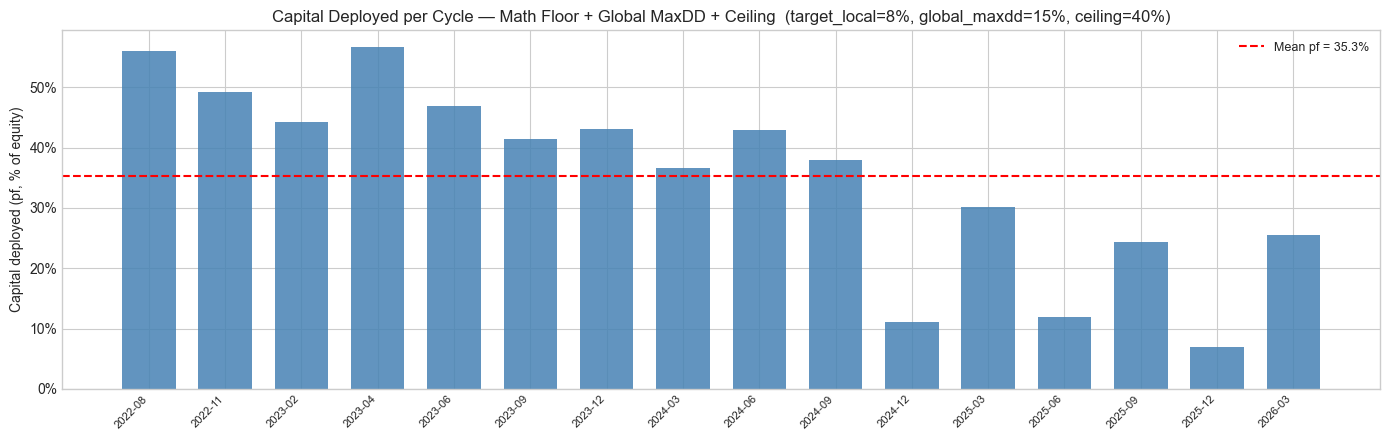

Mean pf across 16 cycles: 35.3%  (min 6.9%, max 56.6%)
Green bars = cycle ended in a ceiling trigger.


In [51]:
# ── Capital deployed per cycle (pf) — Math Floor + Global MaxDD + Ceiling ─────
fig, ax = plt.subplots(figsize=(14, 4.5))
x      = list(range(len(cdf_full)))
labels = [d.strftime('%Y-%m') for d in cdf_full['start']]
colors = ['seagreen' if c else 'steelblue' for c in cdf_full['ceiling']]

ax.bar(x, cdf_full['pf'] * 100, color=colors, alpha=0.85, width=0.7)

mean_pf = cdf_full['pf'].mean() * 100
ax.axhline(mean_pf, color='red', ls='--', lw=1.5, label=f'Mean pf = {mean_pf:.1f}%')
ax.axhline(0, color='black', lw=0.5)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Capital deployed (pf, % of equity)')
ax.set_title(
    f'Capital Deployed per Cycle — Math Floor + Global MaxDD + Ceiling  '
    f'(target_local={TARGET_LOCAL:.0%}, global_maxdd={GLOBAL_MAXDD:.0%}, ceiling={CEILING:.0%})'
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('../../observations/strategies/sandbox/dynamic_notional_pf_per_cycle.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean pf across {len(cdf_full)} cycles: {mean_pf:.1f}%  '
      f'(min {cdf_full["pf"].min()*100:.1f}%, max {cdf_full["pf"].max()*100:.1f}%)')
print('Green bars = cycle ended in a ceiling trigger.')